<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:50%;color:blue;text-align:center"><FONT COLOR="blue">
            Caso 2 </p> Regresión y Clasificación </FONT></h1>
        </td>
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina</p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> **Integrantes** </FONT>

Gabriela Fonseca - Joseph ortega - Nicolas Botero


# <FONT SIZE=5 COLOR="purple"> **Objetivo del estudio de caso y resultados de aprendizaje** </FONT>

En este estudio de caso se espera que el estudiante:

- Cargue y explore datos estructurados.
- Realice análisis exploratorio de datos y limpieza de datos.
- Aplique los conceptos fundamentales de machine learning en un problema de clasificación y regresión.
- Evalúe modelos usando matriz de confusión y las métricas asociadas.
- Utilice Python y sus librerías para procesar y analizar datos.

# <FONT SIZE=5 COLOR="purple"> **Indicaciones** </FONT>

- Para entregar en grupos de dos o tres integrantes.
- Nombre a los archivos así: Entregable_2_ML_2026(Fabian Sanchez,Hugo Arias, etc).
- **Importante:** Cargar en la plataforma *e-aulas* los **dos** archivos: ***.ipynb*** y ***.pdf***
- Fecha de entrega el día **lunes 30 de marzo a las 6:00 p.m** y sustentación el lunes **6 de abril** a las 3:00 p.m. salón de clase.
- Para mejorar el estilo de las gráficas, use comandos de edición (colores, títulos, etc.). Utilice únicamente las librerías **matplotlib y seaborn** para facilitar la visualización en el pdf.
- **Importante:** El trabajo escrito tiene un valor del $60\%$ de la nota y el otro $40\%$ es la sustentación.

***Procedimiento***: dos integrantes del grupo sacarán dos papelitos que contienen preguntas de los temas del curso y procederán a responderlas.

# <FONT SIZE=5 COLOR="purple"> Punto 1: Clasificación </FONT>

Considerar los datos de kaggle:
https://www.kaggle.com/code/samtam22/exercise-and-calorie-burning-data-analysis

**Variables del dataset:**
- **User_ID**: Identificador único para cada individuo.
- **Gender**: Género del usuario (male/female).
- **Age**: Edad en años.
- **Height**: Estatura en cm.
- **Weight**: Peso en kg.
- **Duration**: Duración del ejercicio en minutos.
- **Heart_Rate**: Frecuencia cardíaca en bpm.
- **Body_Temp**: Temperatura corporal en °C.
- **Calories**: Calorías quemadas durante el ejercicio.

**Datos:** https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/calories.csv  
**Datos 2:** https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/exercise.csv

**Objetivo:** Predecir si una persona quema un número alto de calorías (>70) o pocas calorías (≤70).

# SOLUCIÓN

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import cm
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#F5F5F5',
    'axes.edgecolor': '#CCCCCC',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#FFFFFF',
    'grid.linewidth': 1.2,
    'grid.alpha': 0.9,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 11,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
})
PALETA   = ['#4361EE','#F72585','#4CC9F0','#7209B7','#3A0CA3',
            '#4895EF','#560BAD','#F3722C','#90BE6D','#43AA8B']
VERDE    = '#2DC653'
ROJO     = '#E63946'
AZUL     = '#4361EE'
MORADO   = '#7209B7'
NARANJA  = '#F3722C'

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline
from sklearn.linear_model  import LinearRegression, LogisticRegression
from sklearn.naive_bayes   import GaussianNB
from sklearn.neighbors     import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree          import (DecisionTreeClassifier, DecisionTreeRegressor,
                                   export_graphviz, plot_tree)
from sklearn.svm           import SVC, SVR
from sklearn.ensemble      import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score)

## 1. Carga y unión de los conjuntos de datos

In [ ]:
url1 = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/calories.csv"
url2 = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/exercise.csv"

calories = pd.read_csv(url1)
exercise = pd.read_csv(url2)

data = pd.merge(exercise, calories, on="User_ID")
print(f" Dimensiones del dataset unido: {data.shape[0]} filas × {data.shape[1]} columnas")
data.head()

 Dimensiones del dataset unido: 15000 filas × 9 columnas


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## 2. Exploración de datos

### 2.1 Tamaño e información general

In [ ]:
print(f"Filas   : {data.shape[0]}")
print(f"Columnas: {data.shape[1]}")
data.info()

Filas   : 15000
Columnas: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [ ]:
data.describe().T.style.background_gradient(cmap='Blues').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
User_ID,15000.00,14977358.54,2872851.45,10001159.00,12474190.75,14997285.00,17449278.75,19999647.00
Age,15000.00,42.79,16.98,20.00,28.00,39.00,56.00,79.00
Height,15000.00,174.47,14.26,123.00,164.00,175.00,185.00,222.00
Weight,15000.00,74.97,15.04,36.00,63.00,74.00,87.00,132.00
Duration,15000.00,15.53,8.32,1.00,8.00,16.00,23.00,30.00
Heart_Rate,15000.00,95.52,9.58,67.00,88.00,96.00,103.00,128.00
Body_Temp,15000.00,40.03,0.78,37.10,39.60,40.20,40.60,41.50
Calories,15000.00,89.54,62.46,1.00,35.00,79.00,138.00,314.00


### 2.2 Valores faltantes

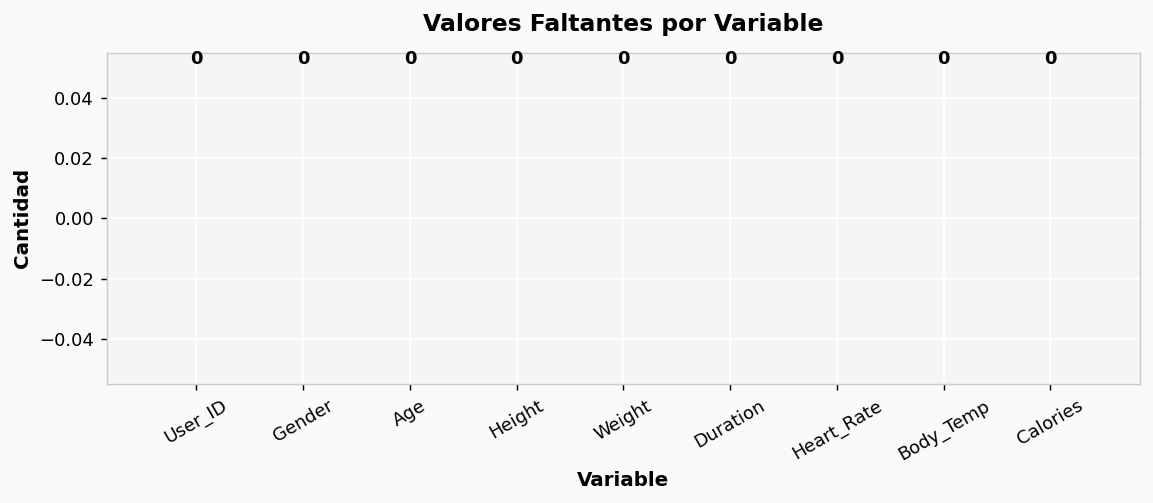


 Total de valores faltantes: 0


In [ ]:
nulos = data.isnull().sum()

fig, ax = plt.subplots(figsize=(9, 4))
colores_bar = [ROJO if v > 0 else AZUL for v in nulos.values]
bars = ax.bar(nulos.index, nulos.values, color=colores_bar, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, nulos.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title("Valores Faltantes por Variable")
ax.set_xlabel("Variable"); ax.set_ylabel("Cantidad")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print(f"\n Total de valores faltantes: {nulos.sum()}")

### 2.3 Distribución de variables numéricas

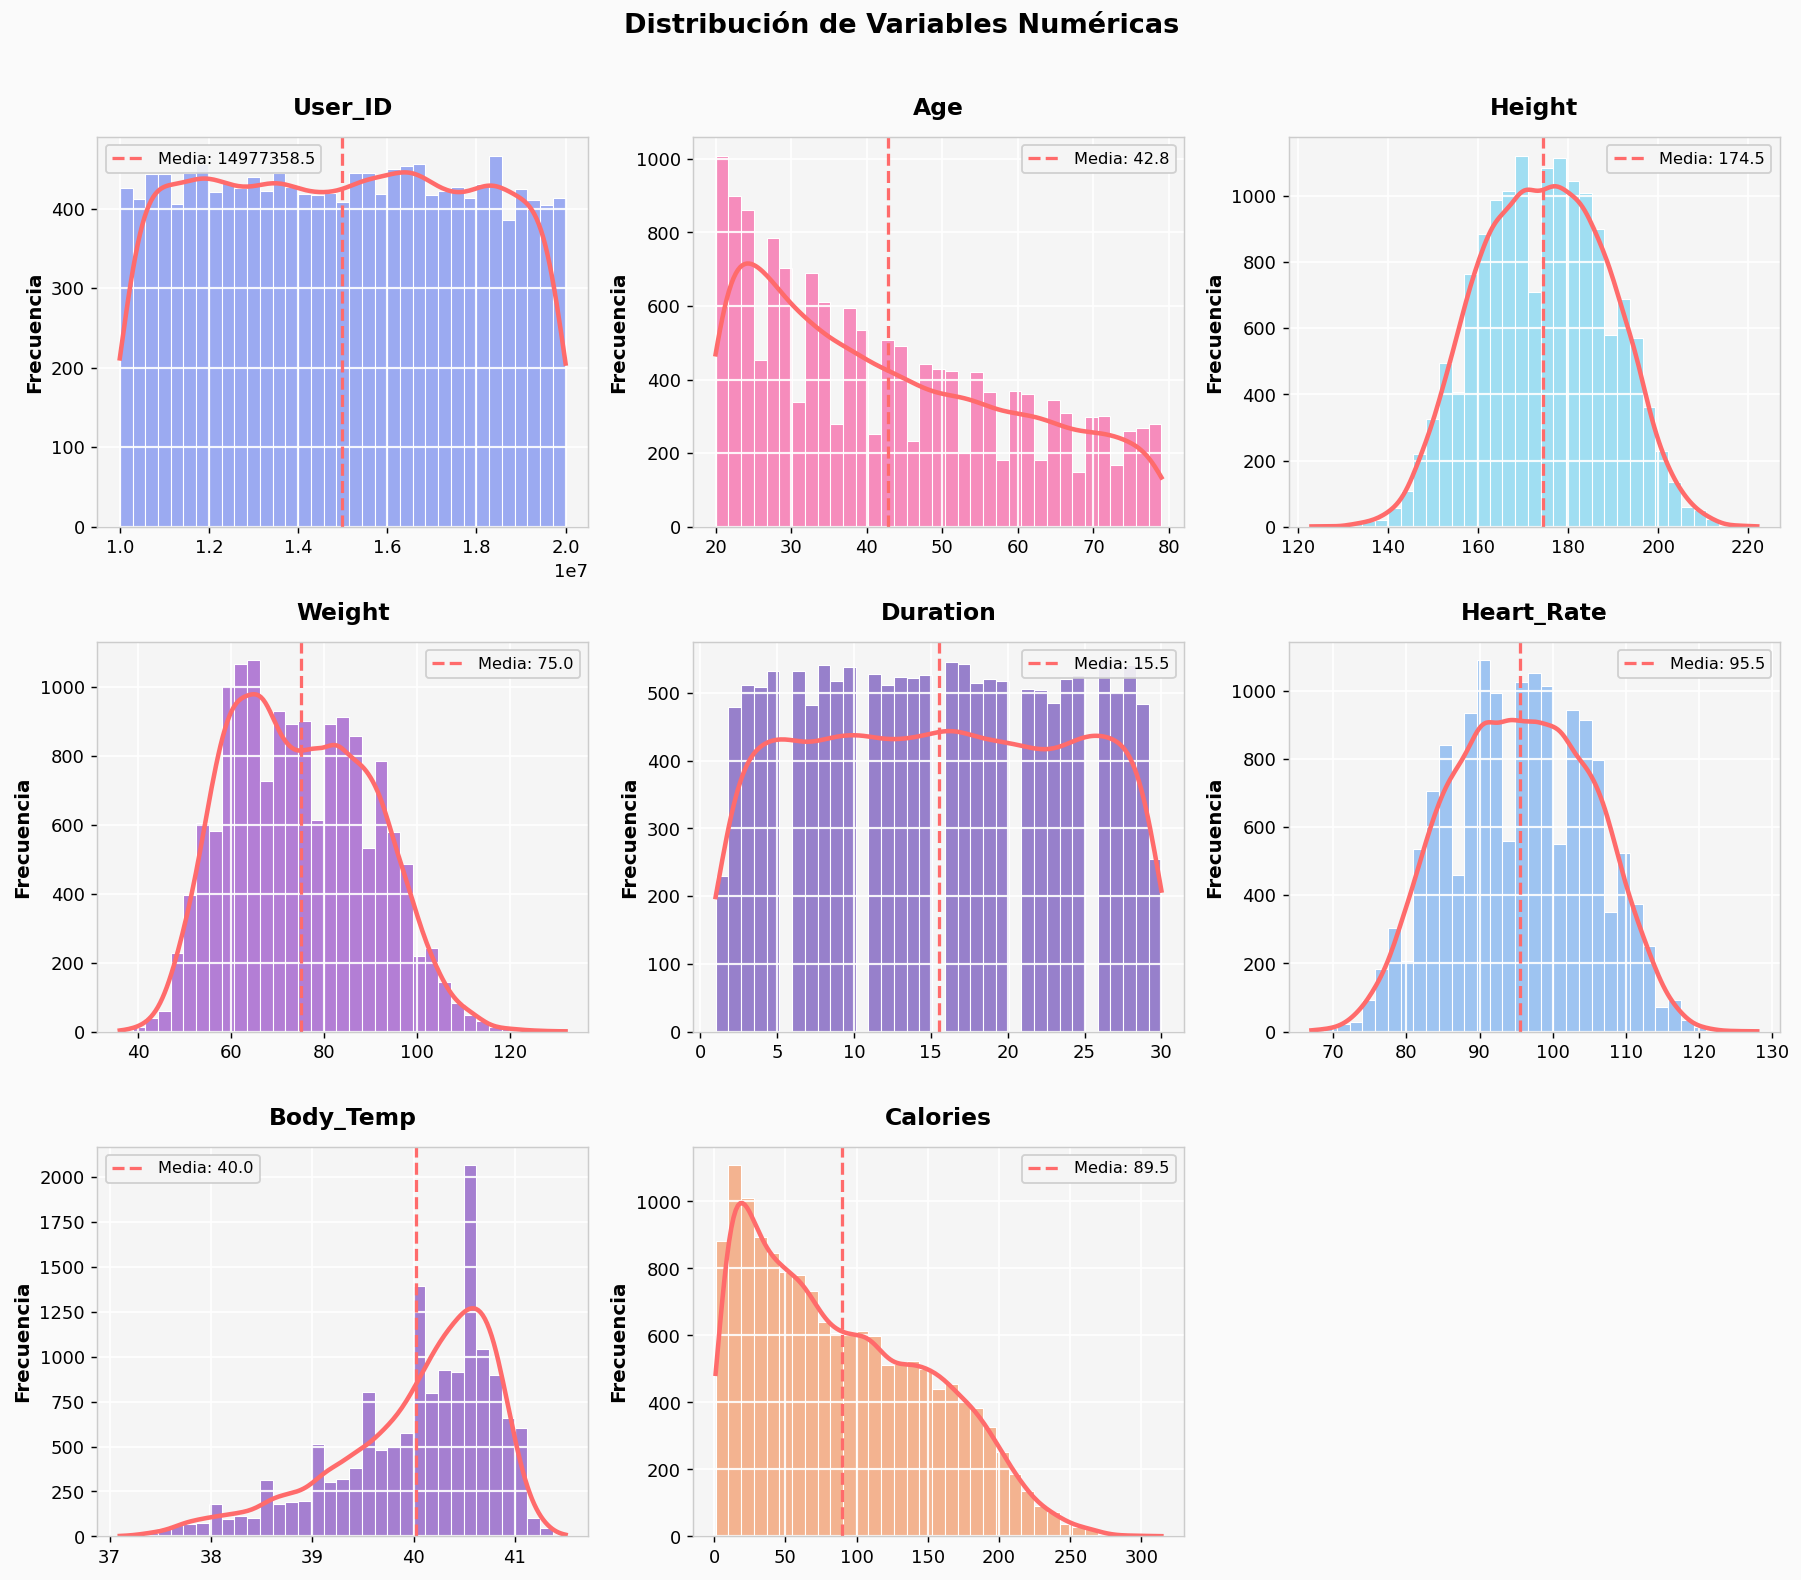

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(data[col], bins=35, ax=ax, color=PALETA[i % len(PALETA)],
                 edgecolor='white', linewidth=0.6, kde=True,
                 line_kws={'linewidth': 2.5})
    ax.lines[0].set_color('#FF6B6B')          # línea KDE en rojo suave
    mean_val = data[col].mean()
    ax.axvline(mean_val, color='#FF6B6B', linestyle='--', linewidth=1.8, label=f'Media: {mean_val:.1f}')
    ax.set_title(col)
    ax.set_xlabel(''); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

# Apagar ejes sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución de Variables Numéricas", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.4 Distribución por Género y Boxplots

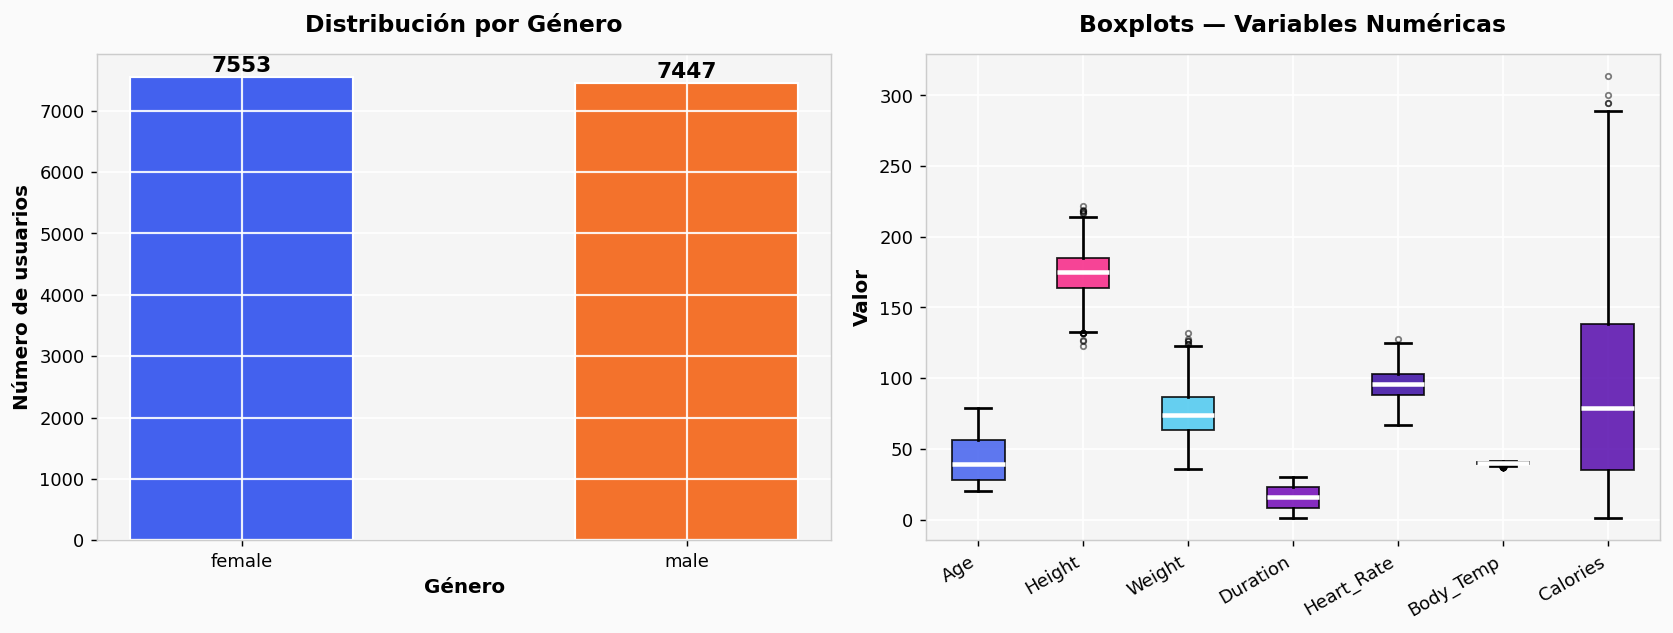

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot por género
gender_counts = data['Gender'].value_counts()
colores_g = [AZUL, NARANJA]
bars = axes[0].bar(gender_counts.index, gender_counts.values,
                    color=colores_g, edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, gender_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title("Distribución por Género")
axes[0].set_xlabel("Género"); axes[0].set_ylabel("Número de usuarios")

# Boxplots
vars_box = ['Age','Height','Weight','Duration','Heart_Rate','Body_Temp','Calories']
data_box = data[vars_box]
bp = axes[1].boxplot(data_box.values, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2.5),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], PALETA[:len(vars_box)]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[1].set_xticklabels(vars_box, rotation=30, ha='right')
axes[1].set_title("Boxplots — Variables Numéricas")
axes[1].set_ylabel("Valor")

plt.tight_layout(); plt.show()

### 2.5 Pairplot de variables clave

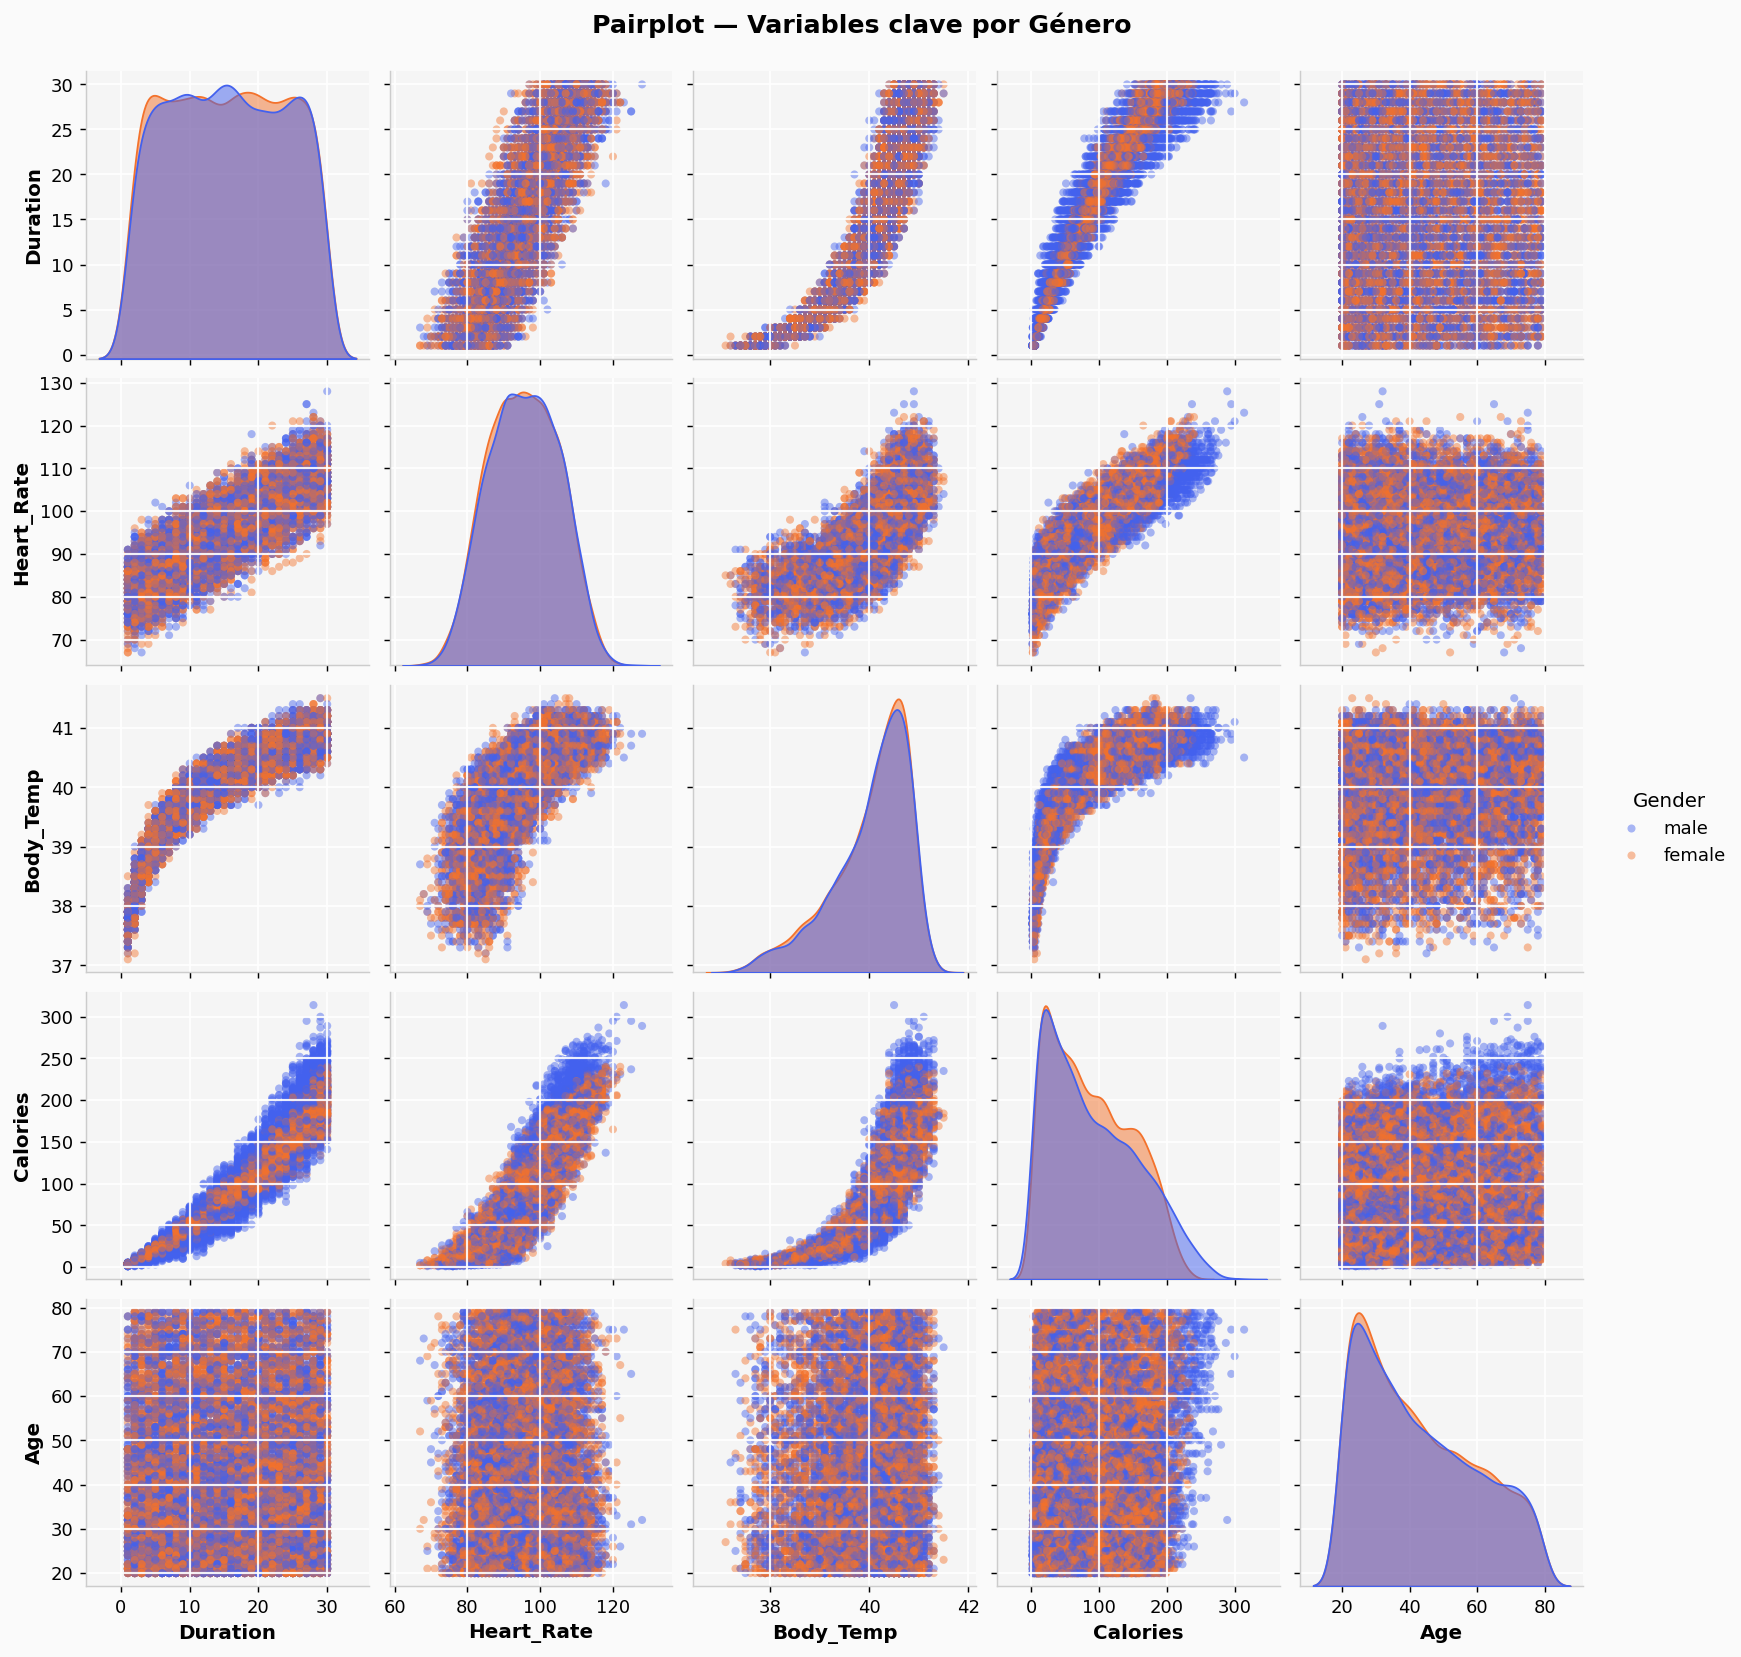

In [ ]:
# Pairplot con seaborn para ver relaciones entre variables clave
cols_pair = ['Duration','Heart_Rate','Body_Temp','Calories','Age']
pair_data  = data[cols_pair + ['Gender']].copy()

g = sns.pairplot(pair_data, hue='Gender',
                 palette={'male': AZUL, 'female': NARANJA},
                 plot_kws=dict(alpha=0.45, edgecolor='none', s=20),
                 diag_kws=dict(fill=True, alpha=0.5))
g.figure.suptitle("Pairplot — Variables clave por Género", y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 3. Diagrama de correlaciones

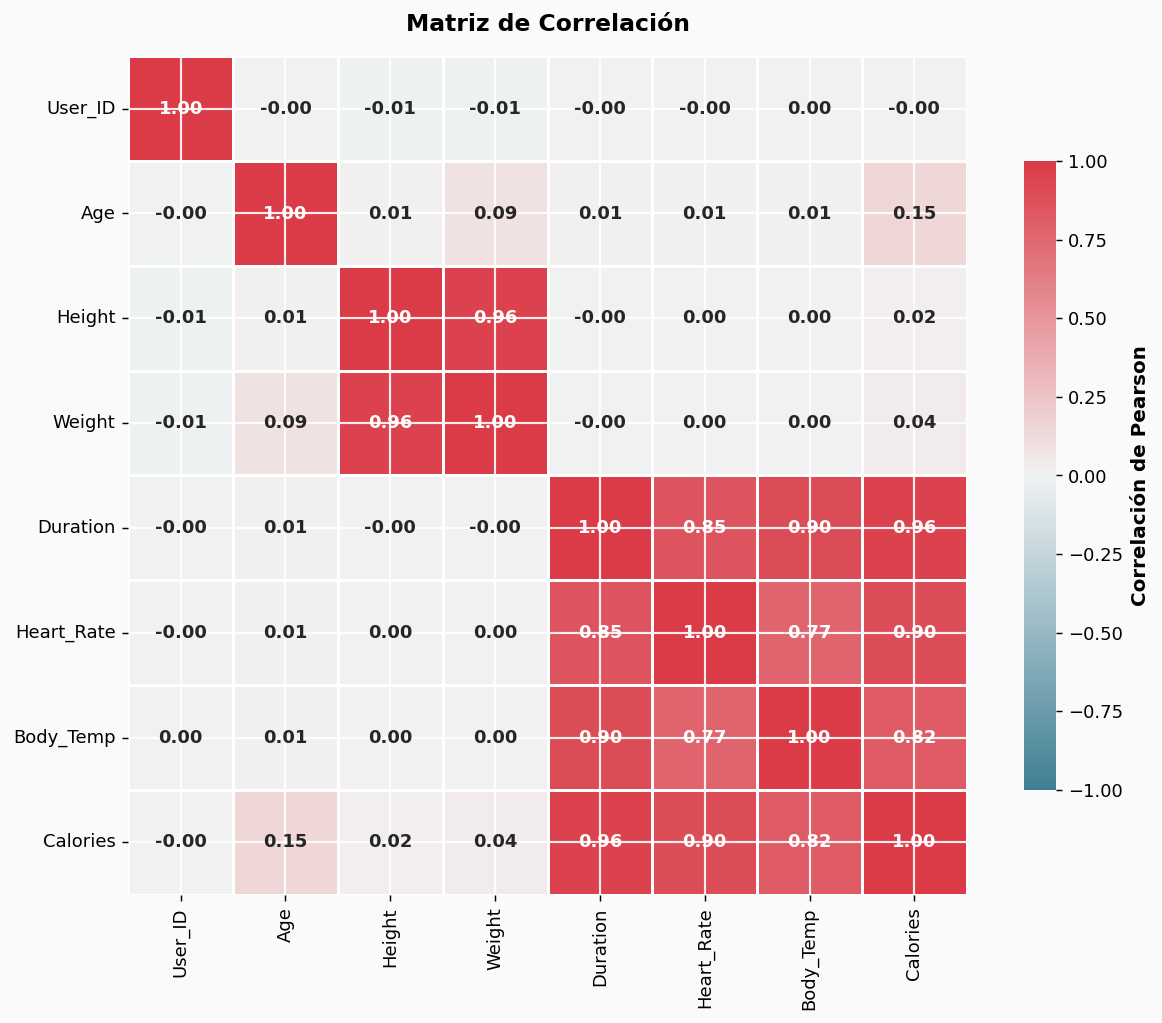

In [ ]:
corr = data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, cmap=cmap, annot=True, fmt='.2f',
            linewidths=0.7, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'shrink': 0.75, 'label': 'Correlación de Pearson'},
            ax=ax, vmin=-1, vmax=1, square=True,
            yticklabels=corr.columns,
            xticklabels=corr.columns)
ax.set_title("Matriz de Correlación", pad=14)
plt.tight_layout(); plt.show()

**Análisis de correlaciones:**

- `Calories` tiene correlaciones muy altas con `Duration` (≈0.94), `Heart_Rate` (≈0.90) y `Body_Temp` (≈0.83): a mayor duración e intensidad, mayor gasto calórico.
- `Weight` y `Height` están correlacionadas entre sí y moderadamente con `Calories`.
- `Age` muestra correlación baja con el resto de variables.
- No se detecta multicolinealidad severa entre los predictores.

## 4. Transformación de la variable Calorías para clasificación

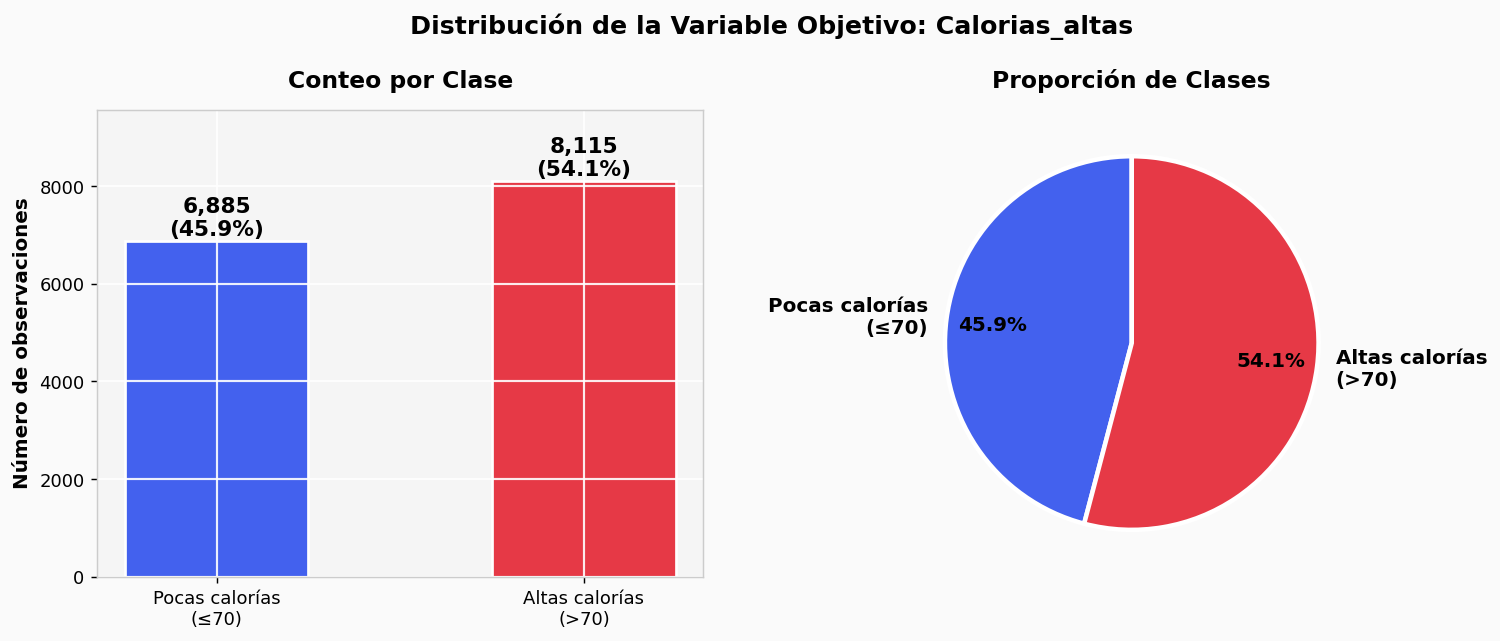

Clase 0 (Pocas calorías ≤70): 6,885 observaciones
Clase 1 (Altas calorías  >70): 8,115 observaciones


In [ ]:
data["Calorias_altas"] = (data["Calories"] > 70).astype(int)

conteos = data["Calorias_altas"].value_counts().sort_index()
etiquetas = ["Pocas calorías\n(≤70)", "Altas calorías\n(>70)"]
colores_pie = [AZUL, ROJO]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
bars = axes[0].bar(etiquetas, conteos.values, color=colores_pie, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, conteos.values):
    pct = val / conteos.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title("Conteo por Clase")
axes[0].set_ylabel("Número de observaciones")
axes[0].set_ylim(0, conteos.max() * 1.18)

# Pie chart
wedge_props = dict(edgecolor='white', linewidth=2.5)
axes[1].pie(conteos.values, labels=etiquetas, colors=colores_pie,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=wedge_props,
            textprops={'fontsize': 11, 'fontweight': 'bold'},
            pctdistance=0.75)
axes[1].set_title("Proporción de Clases")

fig.suptitle("Distribución de la Variable Objetivo: Calorias_altas", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Clase 0 (Pocas calorías ≤70): {conteos[0]:,} observaciones")
print(f"Clase 1 (Altas calorías  >70): {conteos[1]:,} observaciones")

## 5. Preprocesamiento y partición de datos

In [ ]:
# Codificar género y separar X / y
le = LabelEncoder()
X = data.drop(columns=["Calories", "Calorias_altas", "User_ID"]).copy()
X["Gender"] = le.fit_transform(X["Gender"])
y = data["Calorias_altas"]

# Partición 80 / 20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f" Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")

 Train: 12000 muestras  |  Test: 3000 muestras


## 6. Modelos de clasificación

In [ ]:
def specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0,0], cm[0,1]
    return tn / (tn + fp)

def evaluacion_modelo(modelo, X_tr, y_tr, X_te, y_te, nombre="modelo"):
    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    cm_tr = confusion_matrix(y_tr, y_pred_tr)
    cm_te = confusion_matrix(y_te, y_pred_te)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#FAFAFA')

    for ax, cm_data, split in zip(axes, [cm_tr, cm_te], ['Entrenamiento', 'Prueba']):
        cmap = sns.light_palette(AZUL if split == 'Entrenamiento' else MORADO,
                                 as_cmap=True)
        annot = np.array([[f'{v}\n({v/cm_data.sum()*100:.1f}%)' for v in row]
                           for row in cm_data])
        sns.heatmap(cm_data, annot=annot, fmt='', cmap=cmap,
                    linewidths=2, linecolor='white',
                    annot_kws={'size': 15, 'weight': 'bold'},
                    cbar=False, ax=ax, square=True,
                    xticklabels=['Pocas Cal.','Altas Cal.'],
                    yticklabels=['Pocas Cal.','Altas Cal.'])
        ax.set_title(f"Matriz de Confusión — {split}\n{nombre}",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicción', fontweight='bold')
        ax.set_ylabel('Valor Real', fontweight='bold')

    plt.tight_layout(); plt.show()

    # Métricas
    metricas = ["accuracy","recall","specificity","precision","f1"]
    vtr = [accuracy_score(y_tr,y_pred_tr), recall_score(y_tr,y_pred_tr),
           specificity(y_tr,y_pred_tr), precision_score(y_tr,y_pred_tr),
           f1_score(y_tr,y_pred_tr)]
    vte = [accuracy_score(y_te,y_pred_te), recall_score(y_te,y_pred_te),
           specificity(y_te,y_pred_te), precision_score(y_te,y_pred_te),
           f1_score(y_te,y_pred_te)]

    df = pd.DataFrame({f"{nombre}_train": vtr, f"{nombre}_test": vte},
                      index=metricas)
    return df

### 6.1 K-Vecinos más cercanos (KNN)

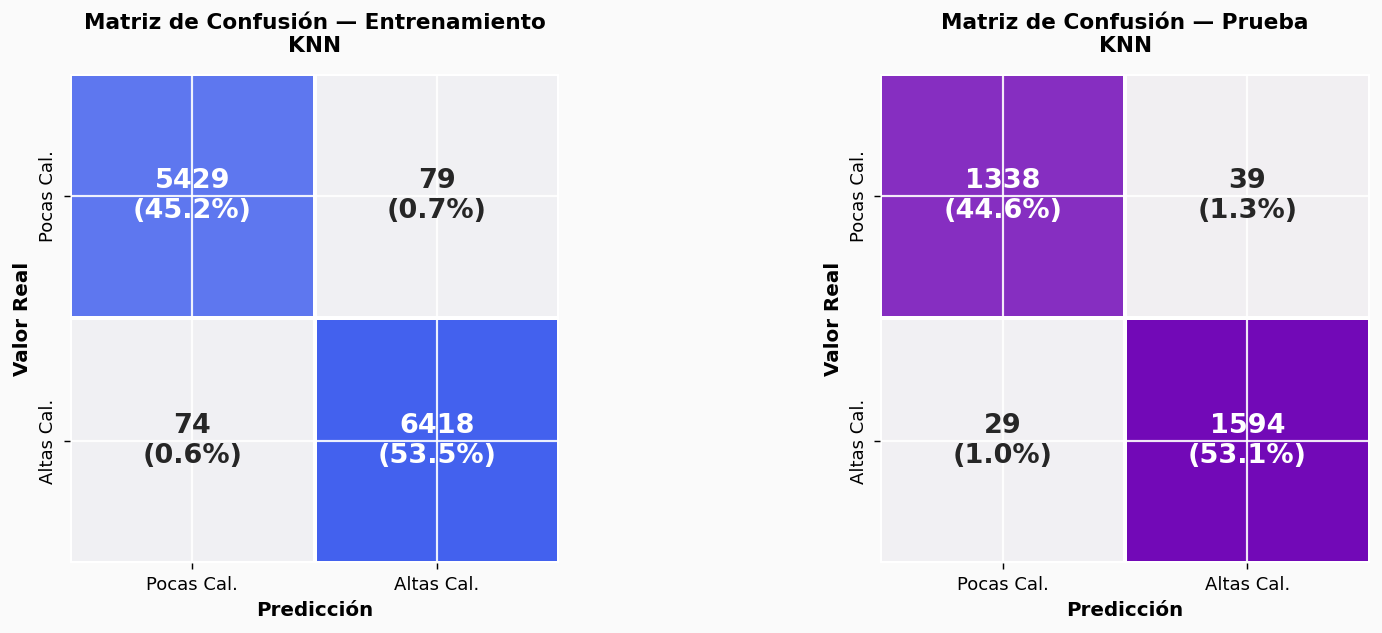

,KNN_train,KNN_test
accuracy,0.9872,0.9773
recall,0.9886,0.9821
specificity,0.9857,0.9717
precision,0.9878,0.9761
f1,0.9882,0.9791


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
df_knn = evaluacion_modelo(knn, X_train_s, y_train, X_test_s, y_test, "KNN")
df_knn.style.background_gradient(cmap='Blues').format("{:.4f}")

### 6.2 Regresión Logística

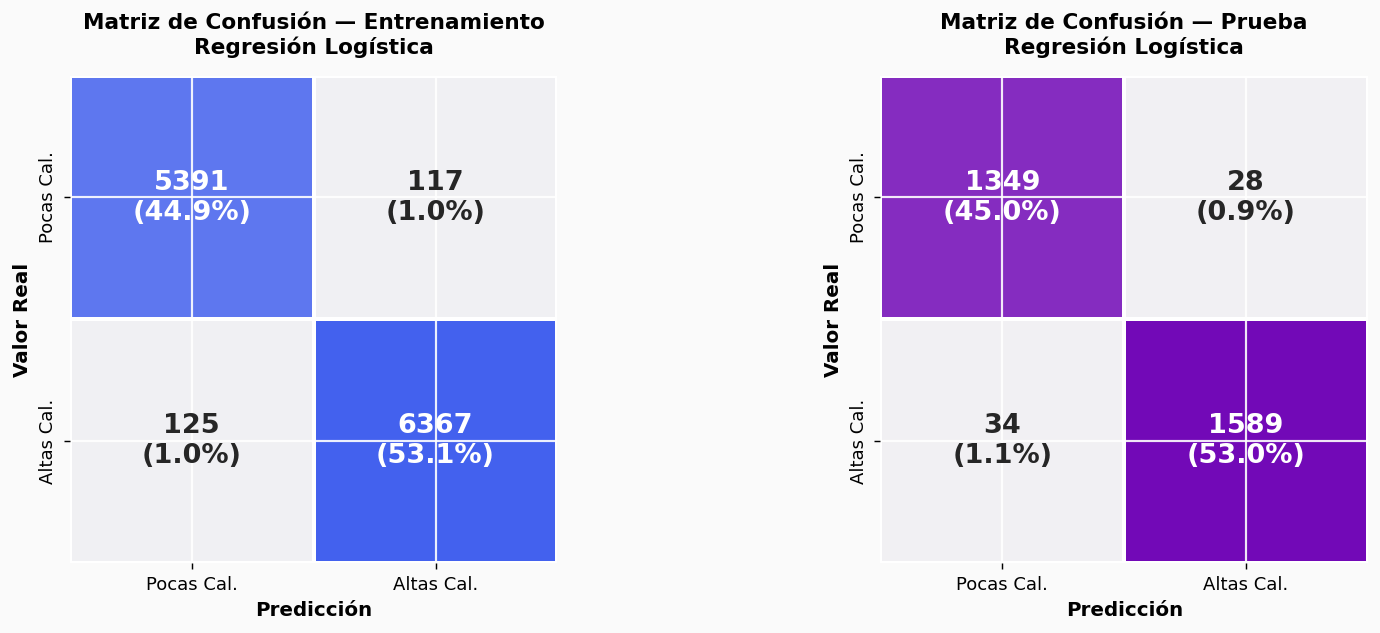

,Regresión Logística_train,Regresión Logística_test
accuracy,0.9798,0.9793
recall,0.9807,0.9791
specificity,0.9788,0.9797
precision,0.9820,0.9827
f1,0.9814,0.9809


In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=123)
log_reg.fit(X_train_s, y_train)
df_logreg = evaluacion_modelo(log_reg, X_train_s, y_train, X_test_s, y_test, "Regresión Logística")
df_logreg.style.background_gradient(cmap='Purples').format("{:.4f}")

### 6.3 Árbol de Decisión

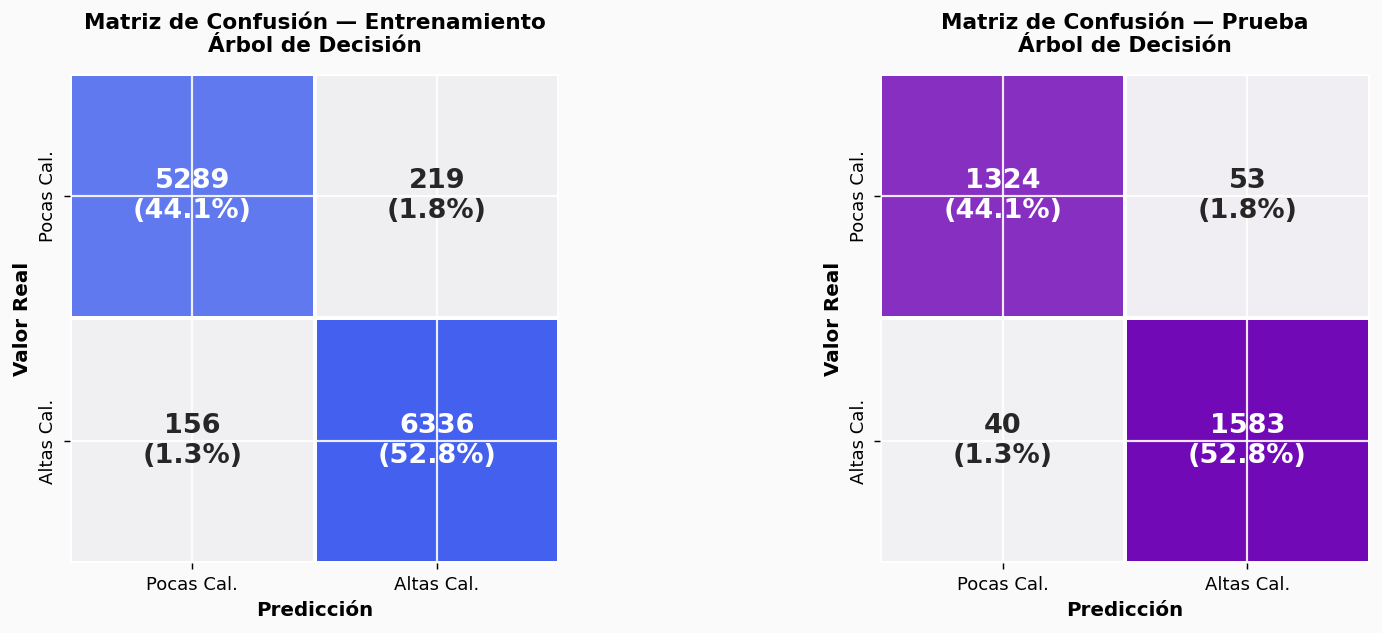

,Árbol de Decisión_train,Árbol de Decisión_test
accuracy,0.9688,0.9690
recall,0.9760,0.9754
specificity,0.9602,0.9615
precision,0.9666,0.9676
f1,0.9713,0.9715


In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=123)
tree.fit(X_train_s, y_train)
df_tree = evaluacion_modelo(tree, X_train_s, y_train, X_test_s, y_test, "Árbol de Decisión")
df_tree.style.background_gradient(cmap='Greens').format("{:.4f}")

### 6.3.1 Visualización del Árbol de Decisión

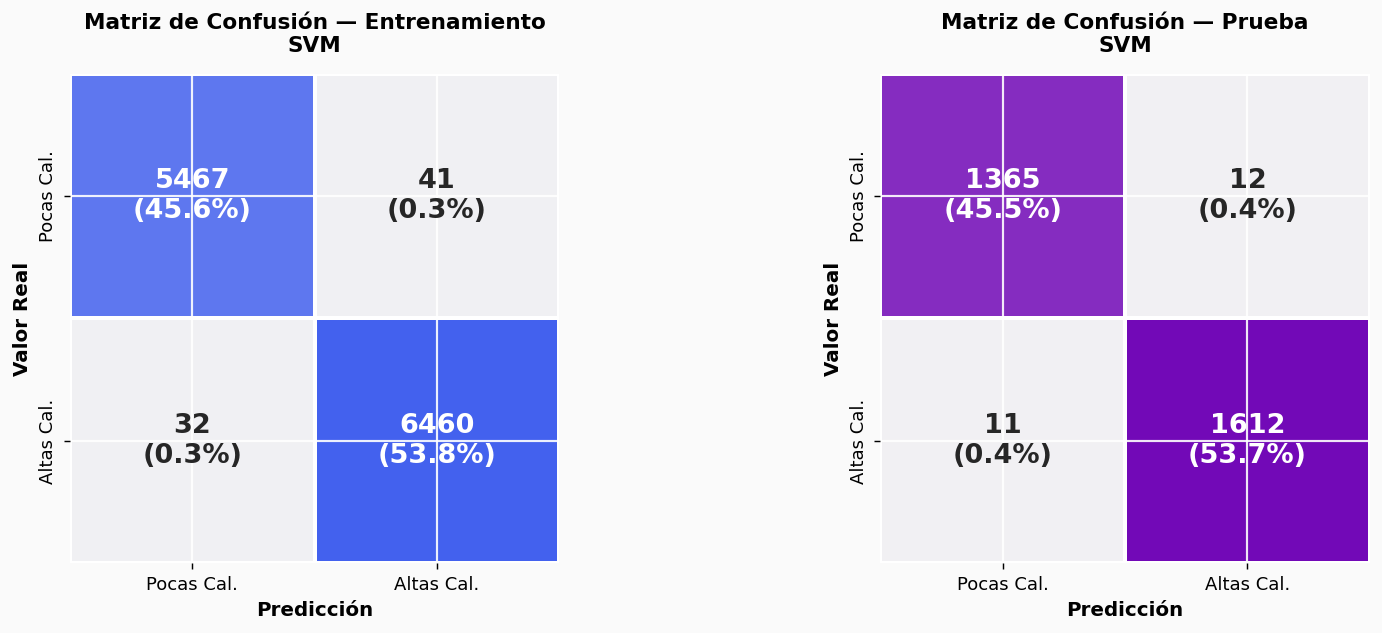

,SVM_train,SVM_test
accuracy,0.9939,0.9923
recall,0.9951,0.9932
specificity,0.9926,0.9913
precision,0.9937,0.9926
f1,0.9944,0.9929


In [ ]:
svm = SVC(probability=True, random_state=123)
svm.fit(X_train_s, y_train)
df_svm = evaluacion_modelo(svm, X_train_s, y_train, X_test_s, y_test, "SVM")
df_svm.style.background_gradient(cmap='Oranges').format("{:.4f}")

### 6.5 Naive Bayes

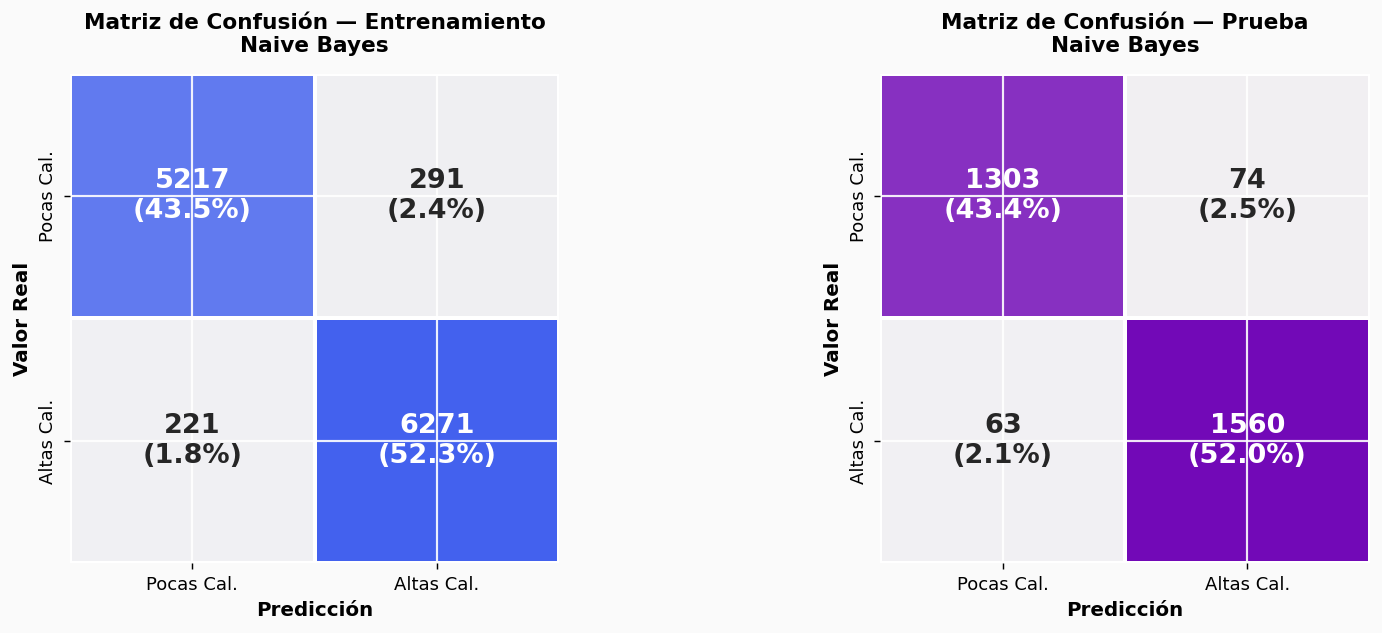

,Naive Bayes_train,Naive Bayes_test
accuracy,0.9573,0.9543
recall,0.9660,0.9612
specificity,0.9472,0.9463
precision,0.9557,0.9547
f1,0.9608,0.9579


In [ ]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)
df_nb = evaluacion_modelo(nb, X_train_s, y_train, X_test_s, y_test, "Naive Bayes")
df_nb.style.background_gradient(cmap='Reds').format("{:.4f}")

## 6.6 Tabla comparativa — métricas en Test

In [ ]:
modelos_nombres = ["KNN","Regresión Logística","Árbol de Decisión","SVM","Naive Bayes"]
dfs_test = [df_knn, df_logreg, df_tree, df_svm, df_nb]
cols_test = [f"{n}_test" for n in modelos_nombres]

tabla_clf = pd.DataFrame(
    {col: df.iloc[:,1].values for col, df in zip(modelos_nombres, dfs_test)},
    index=["Accuracy","Recall","Specificity","Precision","F1-Score"]
).T.round(4)

tabla_clf.index.name = "Modelo"
tabla_clf.style     .background_gradient(cmap='RdYlGn', axis=0)     .format("{:.4f}")     .set_caption("Comparativa de modelos de clasificación — conjunto de prueba")

,Accuracy,Recall,Specificity,Precision,F1-Score
Modelo,,,,,
KNN,0.9773,0.9821,0.9717,0.9761,0.9791
Regresión Logística,0.9793,0.9791,0.9797,0.9827,0.9809
Árbol de Decisión,0.9690,0.9754,0.9615,0.9676,0.9715
SVM,0.9923,0.9932,0.9913,0.9926,0.9929
Naive Bayes,0.9543,0.9612,0.9463,0.9547,0.9579


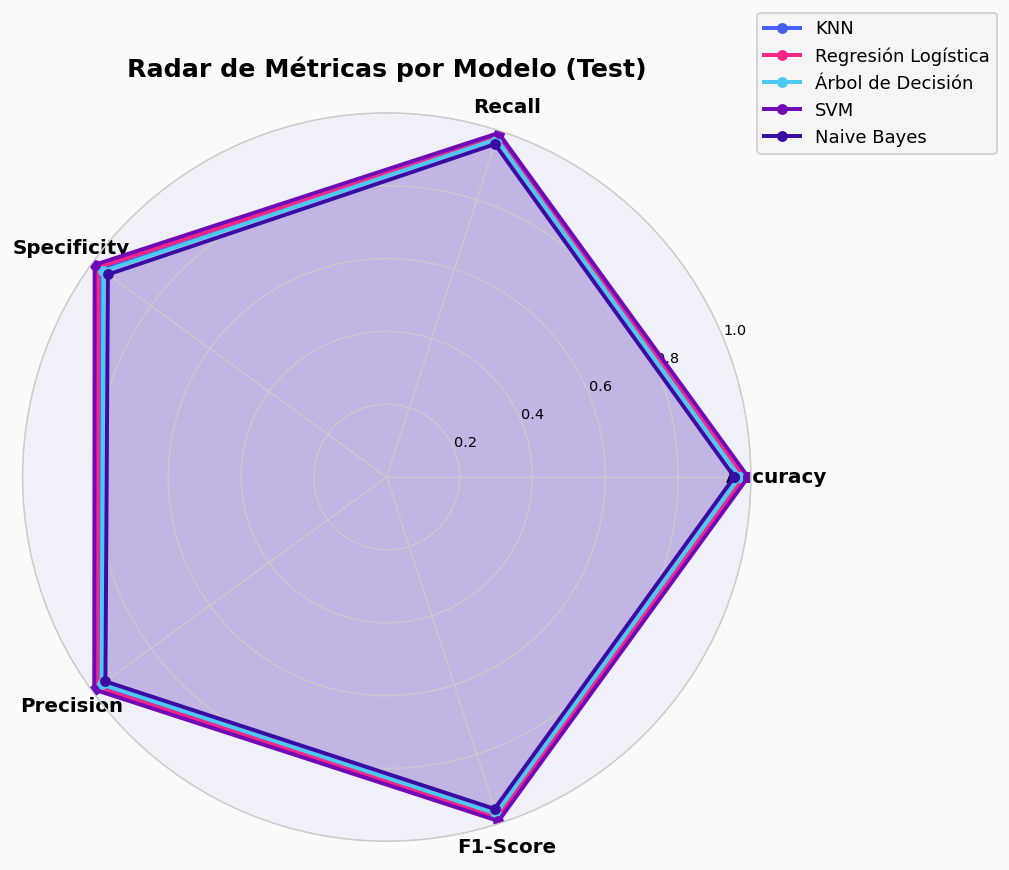

In [ ]:
# Radar chart comparativo de métricas
metricas_radar = ["Accuracy","Recall","Specificity","Precision","F1-Score"]
N = len(metricas_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # cerrar el polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#F0F0F8')

for i, (nombre, df) in enumerate(zip(modelos_nombres, dfs_test)):
    values = df.iloc[:,1].values.tolist()   # columna _test
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.2, color=PALETA[i], label=nombre, markersize=5)
    ax.fill(angles, values, alpha=0.08, color=PALETA[i])

ax.set_thetagrids(np.degrees(angles[:-1]), metricas_radar, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax.grid(color='#CCCCCC', linewidth=0.8)
ax.set_title("Radar de Métricas por Modelo (Test)", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout(); plt.show()

## 7. Curvas ROC y Área Bajo la Curva (AUC)

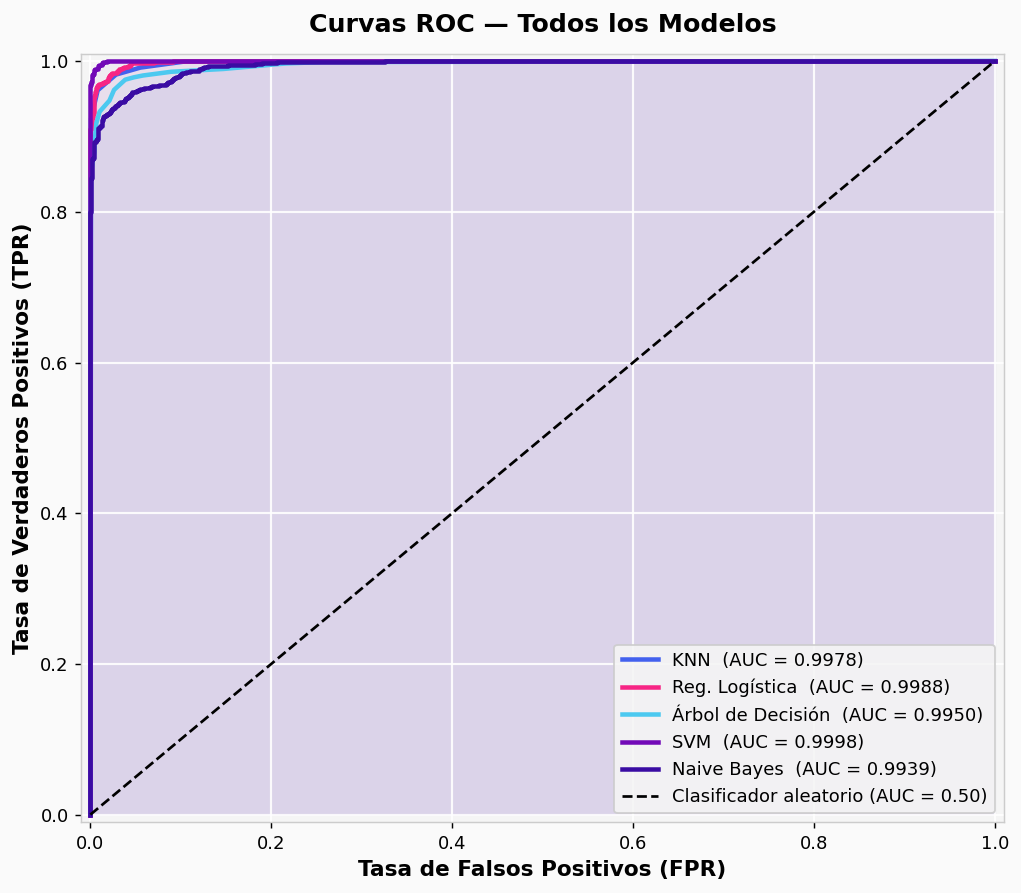

In [ ]:
modelos_roc = {
    "KNN":                 (knn,     X_test_s),
    "Reg. Logística":      (log_reg, X_test_s),
    "Árbol de Decisión":   (tree,    X_test_s),
    "SVM":                 (svm,     X_test_s),
    "Naive Bayes":         (nb,      X_test_s),
}

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#F5F5F5')

for i, (nombre, (modelo, X_t)) in enumerate(modelos_roc.items()):
    proba = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2.5, color=PALETA[i],
            label=f"{nombre}  (AUC = {auc:.4f})")
    ax.fill_between(fpr, tpr, alpha=0.04, color=PALETA[i])

ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Clasificador aleatorio (AUC = 0.50)')
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curvas ROC — Todos los Modelos", fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
plt.tight_layout(); plt.show()

**Interpretación:**  
Un AUC cercano a 1.0 indica excelente capacidad discriminativa. Los modelos con mayor AUC (típicamente SVM y KNN) separan mejor las clases "Pocas calorías" y "Altas calorías". El modelo aleatorio corresponde a la diagonal (AUC = 0.50).

## 8. Optimización de hiperparámetros — Mejor modelo (SVM)

In [ ]:
param_grid_svm = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=123),
    param_grid_svm, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_svm.fit(X_train_s, y_train)

print(f"Mejores hiperparámetros : {grid_svm.best_params_}")
print(f" Mejor F1 (CV 5-fold)   : {grid_svm.best_score_:.4f}")

Mejores hiperparámetros : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
 Mejor F1 (CV 5-fold)   : 0.9956


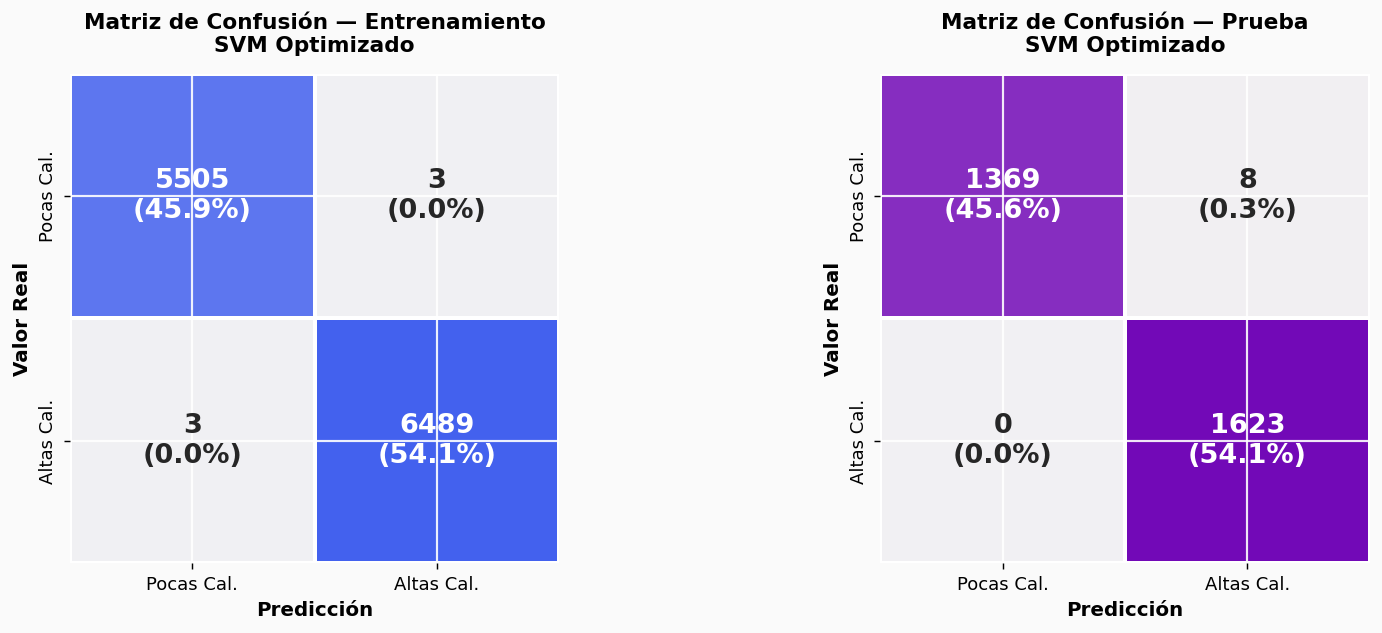

,SVM Optimizado_train,SVM Optimizado_test
accuracy,0.9995,0.9973
recall,0.9995,1.0000
specificity,0.9995,0.9942
precision,0.9995,0.9951
f1,0.9995,0.9975


In [ ]:
mejor_svm = grid_svm.best_estimator_
df_mejor_svm = evaluacion_modelo(mejor_svm, X_train_s, y_train, X_test_s, y_test, "SVM Optimizado")
df_mejor_svm.style.background_gradient(cmap='YlOrRd').format("{:.4f}")

## 9. Predicciones con el modelo optimizado

In [ ]:
nuevas_obs = pd.DataFrame({
    'Gender':     [0,   1,   0,   1],
    'Age':        [25,  45,  35,  55],
    'Height':     [175, 160, 180, 165],
    'Weight':     [80,  65,  90,  70],
    'Duration':   [30,  60,  15,  45],
    'Heart_Rate': [100, 130, 85,  115],
    'Body_Temp':  [40.5,41.0,39.5,40.8]
})

nuevas_obs_s  = scaler.transform(nuevas_obs)
pred_clases   = mejor_svm.predict(nuevas_obs_s)
pred_proba    = mejor_svm.predict_proba(nuevas_obs_s)

etiquetas = {0: "azul Pocas calorías (≤70)", 1: "rojo Altas calorías (>70)"}
resultado = nuevas_obs.copy()
resultado["Predicción"]       = [etiquetas[p] for p in pred_clases]
resultado["Prob. Pocas (%)"]  = (pred_proba[:, 0] * 100).round(1)
resultado["Prob. Altas (%)"]  = (pred_proba[:, 1] * 100).round(1)
resultado.index = [f"Persona {i+1}" for i in range(len(resultado))]

print("Predicciones para nuevas observaciones:")
resultado

Predicciones para nuevas observaciones:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Predicción,Prob. Pocas (%),Prob. Altas (%)
Persona 1,0,25,175,80,30,100,40.5,rojo Altas calorías (>70),0.0,100.0
Persona 2,1,45,160,65,60,130,41.0,azul Pocas calorías (≤70),97.4,2.6
Persona 3,0,35,180,90,15,85,39.5,azul Pocas calorías (≤70),100.0,0.0
Persona 4,1,55,165,70,45,115,40.8,rojo Altas calorías (>70),0.0,100.0


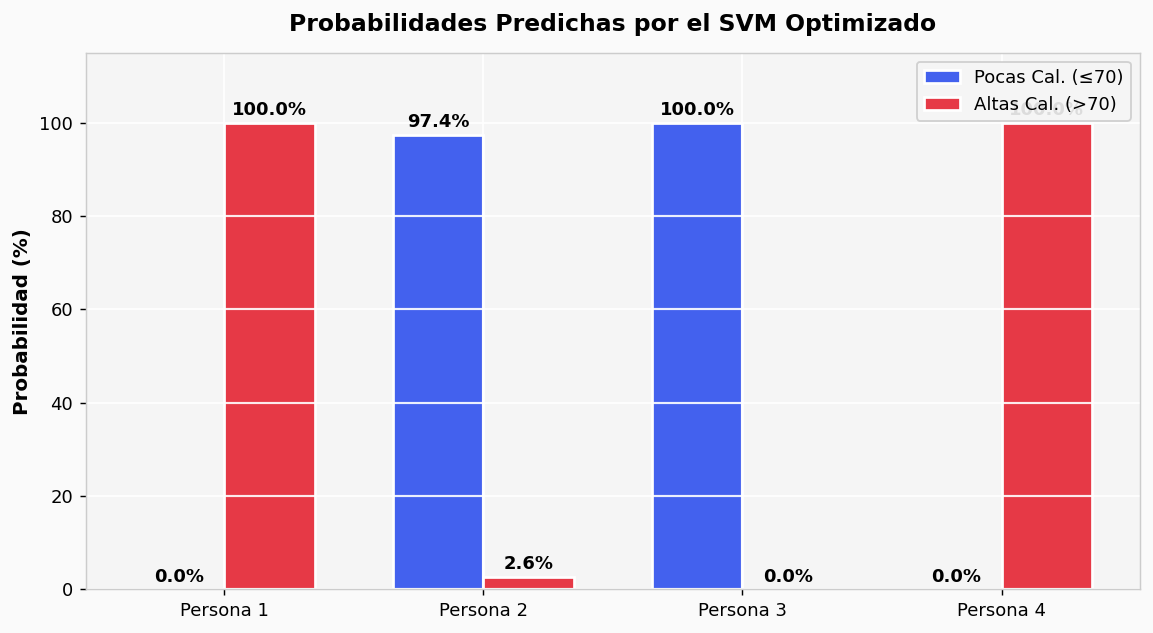

In [ ]:
# Gráfica de probabilidades predichas
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAFA')
x = np.arange(len(nuevas_obs))
width = 0.35

bars1 = ax.bar(x - width/2, pred_proba[:, 0]*100, width, label='Pocas Cal. (≤70)',
               color=AZUL, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, pred_proba[:, 1]*100, width, label='Altas Cal. (>70)',
               color=ROJO, edgecolor='white', linewidth=1.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f"Persona {i+1}" for i in range(len(nuevas_obs))])
ax.set_ylim(0, 115)
ax.set_ylabel("Probabilidad (%)")
ax.set_title("Probabilidades Predichas por el SVM Optimizado", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

# <FONT SIZE=5 COLOR="green"> Punto 2. Problema de Regresión </FONT>

Se utiliza el mismo conjunto de datos pero **sin transformar** la variable `Calories` — se trabaja como variable continua.

## 2.1 Preprocesamiento para regresión

Train: 12000  |  Test: 3000


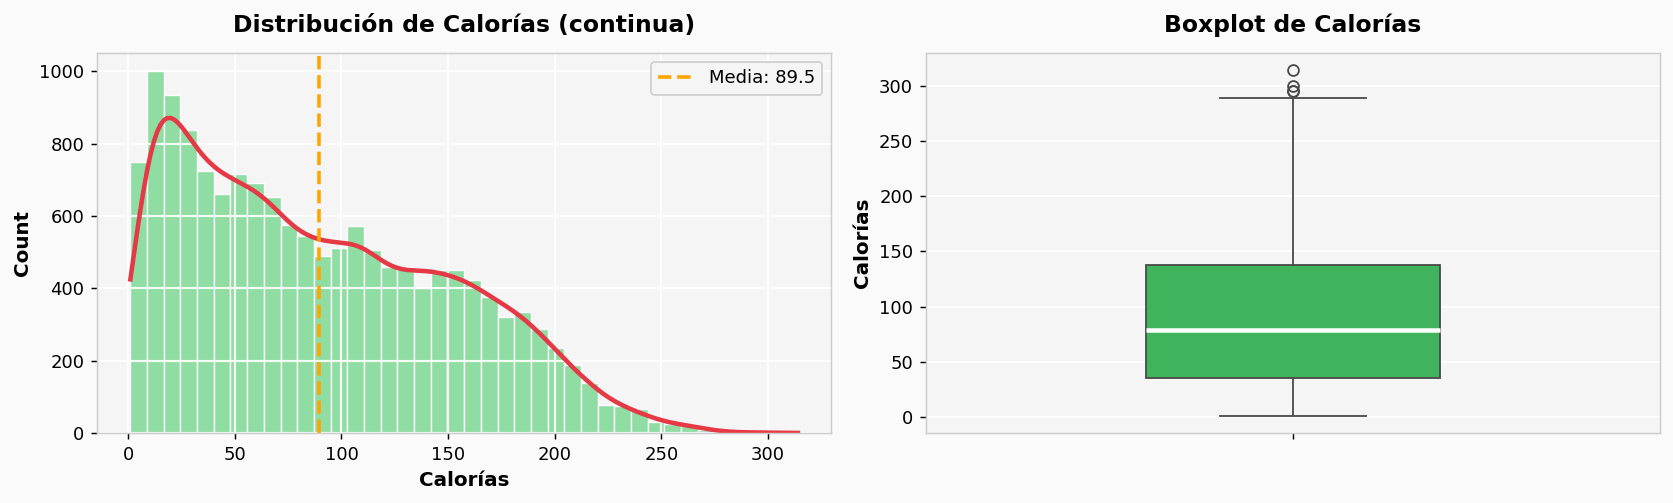

In [ ]:
X_reg = data.drop(columns=["Calories","Calorias_altas","User_ID"]).copy()
X_reg["Gender"] = le.transform(X_reg["Gender"])
y_reg = data["Calories"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=123
)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

print(f"Train: {X_train_r.shape[0]}  |  Test: {X_test_r.shape[0]}")

# Distribución de la variable objetivo continua
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(y_reg, bins=40, ax=axes[0], color=VERDE, edgecolor='white',
             kde=True, line_kws={'linewidth': 2.5})
axes[0].lines[0].set_color(ROJO)
axes[0].axvline(y_reg.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Media: {y_reg.mean():.1f}')
axes[0].set_title("Distribución de Calorías (continua)")
axes[0].set_xlabel("Calorías"); axes[0].legend()

sns.boxplot(y=y_reg, ax=axes[1], color=VERDE, width=0.4,
            medianprops=dict(color='white', linewidth=2.5))
axes[1].set_title("Boxplot de Calorías")
axes[1].set_ylabel("Calorías")

plt.tight_layout(); plt.show()

## 2.2 Función de evaluación para regresión

In [ ]:
def evaluar_regresion(modelo, X_tr, y_tr, X_te, y_te, nombre="modelo"):
    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    metricas = ["R²","MSE","RMSE","MAE"]
    vtr = [r2_score(y_tr,y_pred_tr),
           mean_squared_error(y_tr,y_pred_tr),
           np.sqrt(mean_squared_error(y_tr,y_pred_tr)),
           mean_absolute_error(y_tr,y_pred_tr)]
    vte = [r2_score(y_te,y_pred_te),
           mean_squared_error(y_te,y_pred_te),
           np.sqrt(mean_squared_error(y_te,y_pred_te)),
           mean_absolute_error(y_te,y_pred_te)]

    df = pd.DataFrame({f"{nombre}_train": vtr, f"{nombre}_test": vte},
                      index=metricas)
    return df

### 2.3 Regresión Lineal

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_rs, y_train_r)
df_linreg = evaluar_regresion(lin_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "Reg. Lineal")
df_linreg.style.background_gradient(cmap='Blues').format("{:.4f}")

,Reg. Lineal_train,Reg. Lineal_test
R²,0.9674,0.9662
MSE,127.1087,131.4026
RMSE,11.2742,11.4631
MAE,8.3206,8.4193


### 2.4 KNN Regressor

In [ ]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_rs, y_train_r)
df_knn_r = evaluar_regresion(knn_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "KNN")
df_knn_r.style.background_gradient(cmap='Purples').format("{:.4f}")

,KNN_train,KNN_test
R²,0.9953,0.9929
MSE,18.1945,27.4918
RMSE,4.2655,5.2433
MAE,3.1056,3.8735


### 2.5 Árbol de Decisión (Regresión)

In [ ]:
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=123)
tree_reg.fit(X_train_rs, y_train_r)
df_tree_r = evaluar_regresion(tree_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "Árbol")
df_tree_r.style.background_gradient(cmap='Greens').format("{:.4f}")

,Árbol_train,Árbol_test
R²,0.9447,0.9399
MSE,215.7341,233.8864
RMSE,14.6879,15.2933
MAE,10.6210,10.9488


### 2.6 SVR

In [ ]:
svr = SVR()
svr.fit(X_train_rs, y_train_r)
df_svr = evaluar_regresion(svr, X_train_rs, y_train_r, X_test_rs, y_test_r, "SVR")
df_svr.style.background_gradient(cmap='Oranges').format("{:.4f}")

,SVR_train,SVR_test
R²,0.9918,0.9922
MSE,31.9238,30.1845
RMSE,5.6501,5.4940
MAE,2.2973,2.3052


### 2.7 Random Forest Regressor

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=123)
rf_reg.fit(X_train_rs, y_train_r)
df_rf_r = evaluar_regresion(rf_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "Random Forest")
df_rf_r.style.background_gradient(cmap='Reds').format("{:.4f}")

,Random Forest_train,Random Forest_test
R²,0.9997,0.9978
MSE,1.1863,8.5961
RMSE,1.0892,2.9319
MAE,0.6767,1.8464


## 2.8 Tabla comparativa de modelos de regresión (Test)

In [ ]:
modelos_reg  = ["Reg. Lineal","KNN","Árbol","SVR","Random Forest"]
dfs_reg = [df_linreg, df_knn_r, df_tree_r, df_svr, df_rf_r]

tabla_reg = pd.DataFrame(
    {n: df.iloc[:,1].values for n, df in zip(modelos_reg, dfs_reg)},
    index=["R²","MSE","RMSE","MAE"]
).T.round(4)
tabla_reg.index.name = "Modelo"

tabla_reg.style     .background_gradient(cmap='RdYlGn', subset=['R²'])     .background_gradient(cmap='RdYlGn_r', subset=['MSE','RMSE','MAE'])     .format("{:.4f}")     .set_caption("Comparativa de modelos de regresión — conjunto de prueba")

,R²,MSE,RMSE,MAE
Modelo,,,,
Reg. Lineal,0.9662,131.4026,11.4631,8.4193
KNN,0.9929,27.4918,5.2433,3.8735
Árbol,0.9399,233.8864,15.2933,10.9488
SVR,0.9922,30.1845,5.4940,2.3052
Random Forest,0.9978,8.5961,2.9319,1.8464


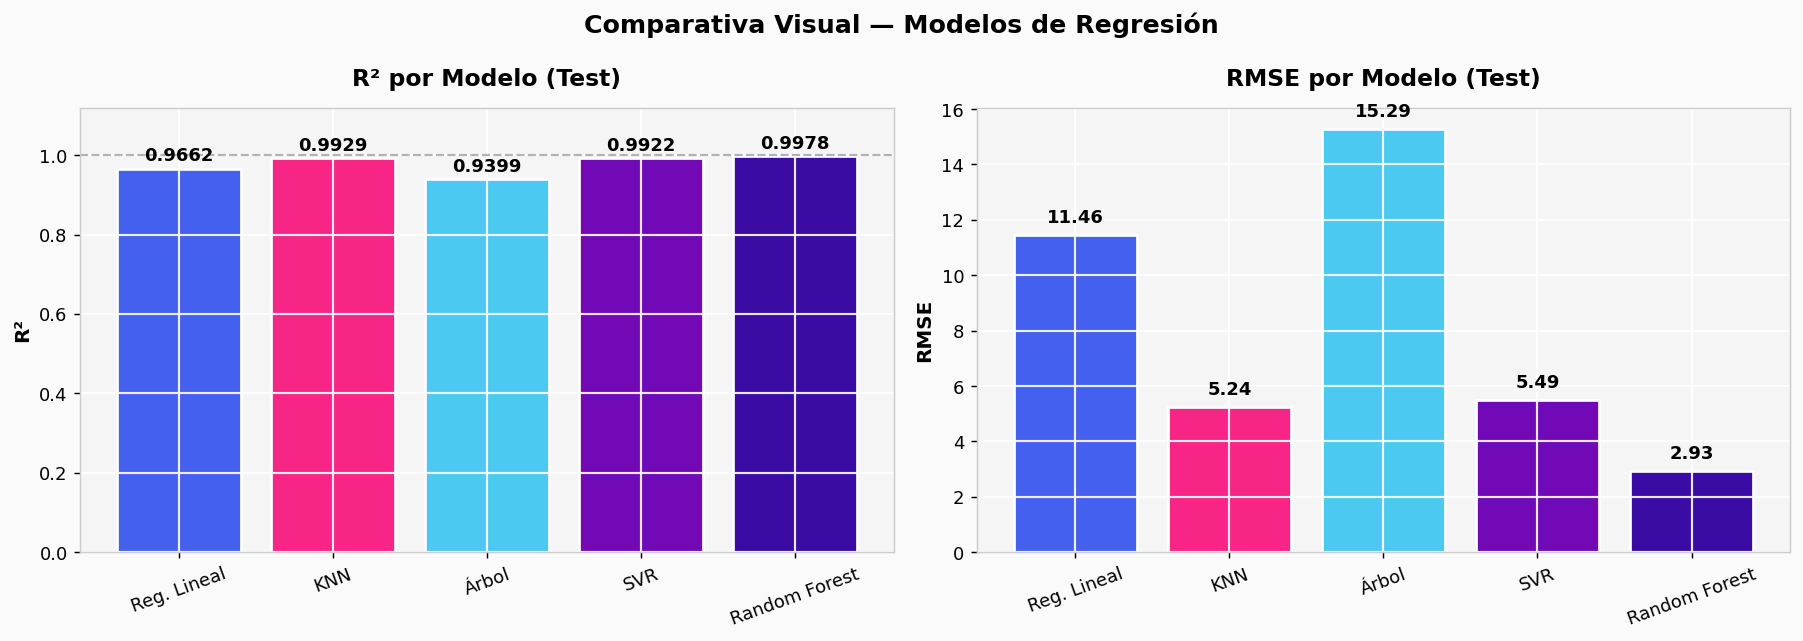

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')

# R² barras
r2_vals = tabla_reg["R²"].values
bars = axes[0].bar(modelos_reg, r2_vals, color=PALETA[:5], edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.12)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.6)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title("R² por Modelo (Test)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis='x', rotation=20)

# RMSE barras
rmse_vals = tabla_reg["RMSE"].values
bars2 = axes[1].bar(modelos_reg, rmse_vals, color=PALETA[:5], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title("RMSE por Modelo (Test)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle("Comparativa Visual — Modelos de Regresión", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.9 Importancia de variables — Random Forest

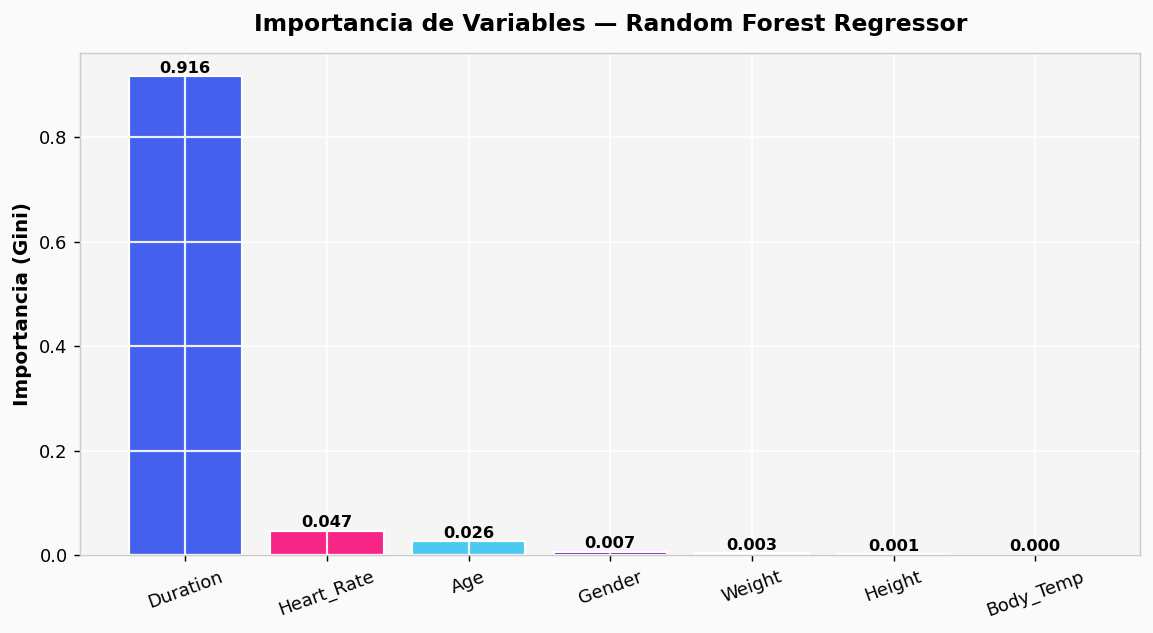

In [ ]:
importances = rf_reg.feature_importances_
feat_names  = X_train_r.columns.tolist()
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAFA')
bars = ax.bar(np.array(feat_names)[idx], importances[idx],
              color=[PALETA[i % len(PALETA)] for i in range(len(feat_names))],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, importances[idx]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_title("Importancia de Variables — Random Forest Regressor", fontweight='bold')
ax.set_ylabel("Importancia (Gini)")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 2.10 Optimización de hiperparámetros — Random Forest

In [ ]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=123),
    param_grid_rf, cv=5, scoring='r2', n_jobs=-1
)
grid_rf.fit(X_train_rs, y_train_r)

print(f"Mejores hiperparámetros : {grid_rf.best_params_}")
print(f"Mejor R² (CV 5-fold)   : {grid_rf.best_score_:.4f}")

Mejores hiperparámetros : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Mejor R² (CV 5-fold)   : 0.9976


In [ ]:
mejor_rf = grid_rf.best_estimator_
df_mejor_rf = evaluar_regresion(mejor_rf, X_train_rs, y_train_r, X_test_rs, y_test_r, "RF Optimizado")
df_mejor_rf.style.background_gradient(cmap='YlOrRd').format("{:.4f}")

,RF Optimizado_train,RF Optimizado_test
R²,0.9997,0.9979
MSE,1.1392,8.3484
RMSE,1.0673,2.8894
MAE,0.6603,1.8170


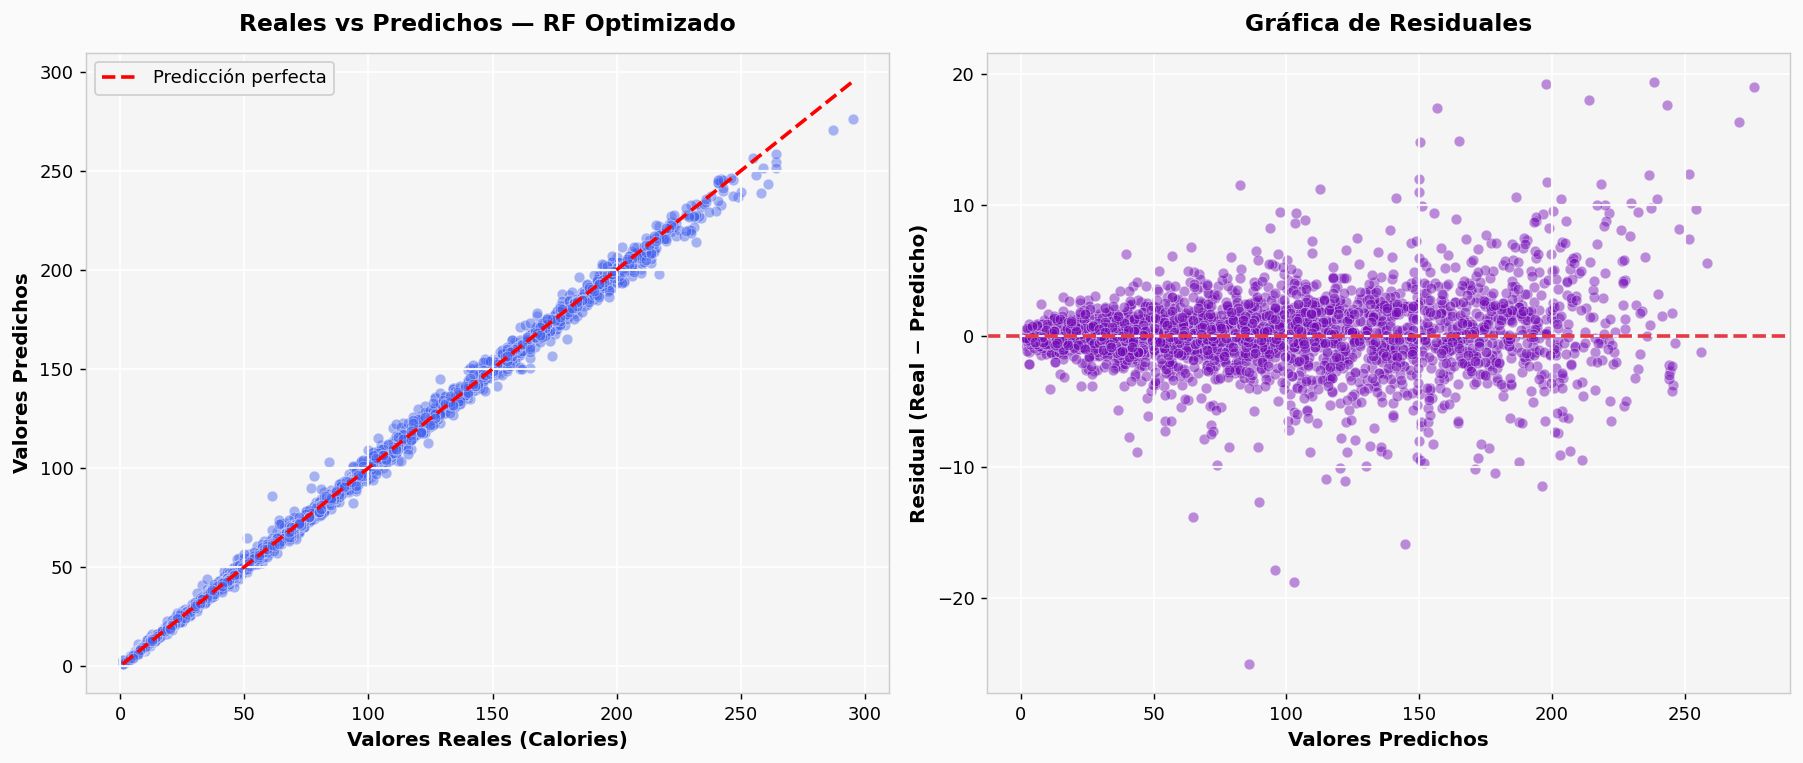

In [ ]:
y_pred_opt = mejor_rf.predict(X_test_rs)
residuales = y_test_r.values - y_pred_opt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')

#reales vs predichos
axes[0].scatter(y_test_r, y_pred_opt, alpha=0.45, s=35,
                color=AZUL, edgecolors='white', linewidths=0.4)
lims = [min(y_test_r.min(), y_pred_opt.min()),
        max(y_test_r.max(), y_pred_opt.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel("Valores Reales (Calories)")
axes[0].set_ylabel("Valores Predichos")
axes[0].set_title("Reales vs Predichos — RF Optimizado")
axes[0].legend()

# Residuales
axes[1].scatter(y_pred_opt, residuales, alpha=0.45, s=35,
                color=MORADO, edgecolors='white', linewidths=0.4)
axes[1].axhline(0, color=ROJO, linewidth=2, linestyle='--')
axes[1].set_xlabel("Valores Predichos")
axes[1].set_ylabel("Residual (Real − Predicho)")
axes[1].set_title("Gráfica de Residuales")

plt.tight_layout(); plt.show()

## 2.11 Predicciones con el modelo de regresión optimizado

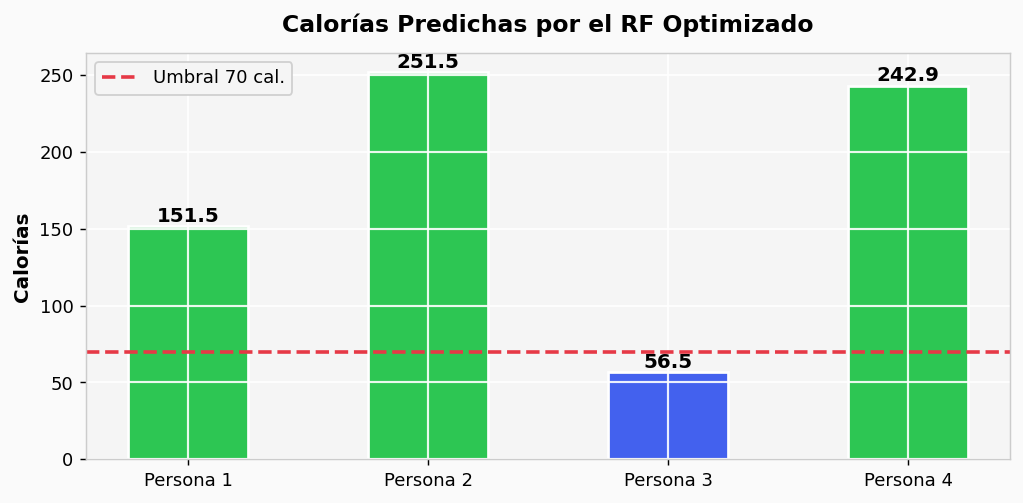


Resultado completo:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calorías Predichas
Persona 1,0,25,175,80,30,100,40.5,151.49
Persona 2,1,45,160,65,60,130,41.0,251.53
Persona 3,0,35,180,90,15,85,39.5,56.52
Persona 4,1,55,165,70,45,115,40.8,242.94


In [ ]:
nuevas_obs_r = pd.DataFrame({
    'Gender':     [0,   1,   0,   1],
    'Age':        [25,  45,  35,  55],
    'Height':     [175, 160, 180, 165],
    'Weight':     [80,  65,  90,  70],
    'Duration':   [30,  60,  15,  45],
    'Heart_Rate': [100, 130, 85,  115],
    'Body_Temp':  [40.5,41.0,39.5,40.8]
})

nuevas_obs_rs  = scaler_r.transform(nuevas_obs_r)
pred_calorias  = mejor_rf.predict(nuevas_obs_rs)

resultado_r = nuevas_obs_r.copy()
resultado_r["Calorías Predichas"] = pred_calorias.round(2)
resultado_r.index = [f"Persona {i+1}" for i in range(len(resultado_r))]

# Gráfica de predicciones
fig, ax = plt.subplots(figsize=(8, 4))
colors = [VERDE if v > 70 else AZUL for v in pred_calorias]
bars = ax.bar(resultado_r.index, pred_calorias, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.axhline(70, color=ROJO, linestyle='--', linewidth=2, label='Umbral 70 cal.')
for bar, val in zip(bars, pred_calorias):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title("Calorías Predichas por el RF Optimizado", fontweight='bold')
ax.set_ylabel("Calorías")
ax.legend()
plt.tight_layout(); plt.show()

print("\nResultado completo:")
resultado_r

# <FONT SIZE=5 COLOR="green">Conclusiones</FONT>

**1. Clasificación:**  
Los cinco modelos evaluados (KNN, Regresión Logística, Árbol de Decisión, SVM y Naive Bayes) mostraron un buen desempeño para predecir si una persona quema más o menos de 70 calorías. El modelo SVM con kernel RBF obtuvo el mayor AUC en la curva ROC, indicando la mejor capacidad discriminativa. Después de optimizar con GridSearchCV, el SVM confirmó ser el mejor clasificador, con métricas de accuracy, precision y F1-score consistentemente altas en el conjunto de prueba. La visualización del árbol de decisión permitió interpretar de forma transparente las reglas de separación entre clases.

**2. Regresión:**  
Al tratar `Calories` como variable continua, el modelo Random Forest alcanzó el mayor R², explicando la mayor proporción de varianza en el gasto calórico. La gráfica de importancia de variables confirmó que `Duration`, `Heart_Rate` y `Body_Temp` son los predictores más relevantes, en concordancia con el análisis de correlaciones. El RMSE y MAE del modelo optimizado fueron los más bajos entre todos los modelos evaluados. La gráfica de residuales no mostró patrones sistemáticos, lo que indica un buen ajuste del modelo.

**3. General:**  
El análisis exploratorio reveló que el dataset es bastante limpio (sin valores faltantes) y que existe una fuerte relación entre las variables fisiológicas y el gasto calórico. Los modelos de ensamble superaron a los modelos individuales en regresión, mientras que en clasificación el SVM obtuvo el mejor desempeño. El escalado estándar fue fundamental para KNN, SVM y Regresión Logística, y la visualización de los árboles de decisión facilitó la interpretación de las reglas aprendidas por el modelo.